In [40]:
import pandas as pd
from io import StringIO
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, accuracy_score

In [41]:
# 1. Load your dataset
df = pd.read_csv('SocialMedia.csv') 
df


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,25/02/2022,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,12/05/2022,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,19/06/2022,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,08/09/2022,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,24/08/2022,Hearth Harmony
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,160282,Men 25-34,Product Launch,15 Days,Pinterest,0.12,$500.00,1.110021,Miami,English,331,2060,1,Health,28/08/2022,Vigor Valley
495,166912,Women 45-60,Product Launch,15 Days,Pinterest,0.12,$500.00,0.260971,Las Vegas,English,331,2061,1,Fashion,08/11/2022,Fiber Fashion
496,711138,Women 18-24,Increase Sales,15 Days,Pinterest,0.02,$500.00,0.294933,Austin,French,331,2061,1,Home,05/05/2022,Living Luxe
497,493940,Men 35-44,Product Launch,15 Days,Instagram,0.04,$500.00,1.910000,Las Vegas,English,565,3193,8,Health,02/04/2022,Pulse Point


In [42]:
# --- STEP 1: TARGET DEFINITION ---
# Creating the new binary column: 1 for Success (> 1.0), 0 for Failure (<= 1.0)
df['Campaign_Status'] = (df['ROI'] > 1.0).astype(int)
df


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company,Campaign_Status
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,25/02/2022,Aura Align,1
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,12/05/2022,Hearth Harmony,1
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,19/06/2022,Cyber Circuit,0
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,08/09/2022,Well Wish,0
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,24/08/2022,Hearth Harmony,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,160282,Men 25-34,Product Launch,15 Days,Pinterest,0.12,$500.00,1.110021,Miami,English,331,2060,1,Health,28/08/2022,Vigor Valley,1
495,166912,Women 45-60,Product Launch,15 Days,Pinterest,0.12,$500.00,0.260971,Las Vegas,English,331,2061,1,Fashion,08/11/2022,Fiber Fashion,0
496,711138,Women 18-24,Increase Sales,15 Days,Pinterest,0.02,$500.00,0.294933,Austin,French,331,2061,1,Home,05/05/2022,Living Luxe,0
497,493940,Men 35-44,Product Launch,15 Days,Instagram,0.04,$500.00,1.910000,Las Vegas,English,565,3193,8,Health,02/04/2022,Pulse Point,1


In [43]:
# --- STEP 2: DURATION CONVERSION ---
# Ensuring Duration is numeric (removing ' days' suffix if present and converting)
df['Duration'] = pd.to_numeric(df['Duration'].astype(str).str.extract('(\d+)')[0])

<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\E-TIME\AppData\Local\Temp\ipykernel_1624\2927628392.py:3: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df['Duration'] = pd.to_numeric(df['Duration'].astype(str).str.extract('(\d+)')[0])


In [ ]:
# --- STEP 3: FEATURE SELECTION & ENCODING ---
# We use One-Hot Encoding for categorical variables so the math works
X = df[['Campaign_Goal', 'Channel_Used', 'Target_Audience', 'Duration']]
X = pd.get_dummies(X, columns=['Campaign_Goal', 'Channel_Used', 'Target_Audience'], drop_first=True)
X
y = df['Campaign_Status']
y

0      1
1      1
2      0
3      0
4      1
      ..
494    1
495    0
496    0
497    1
498    1
Name: Campaign_Status, Length: 499, dtype: int64

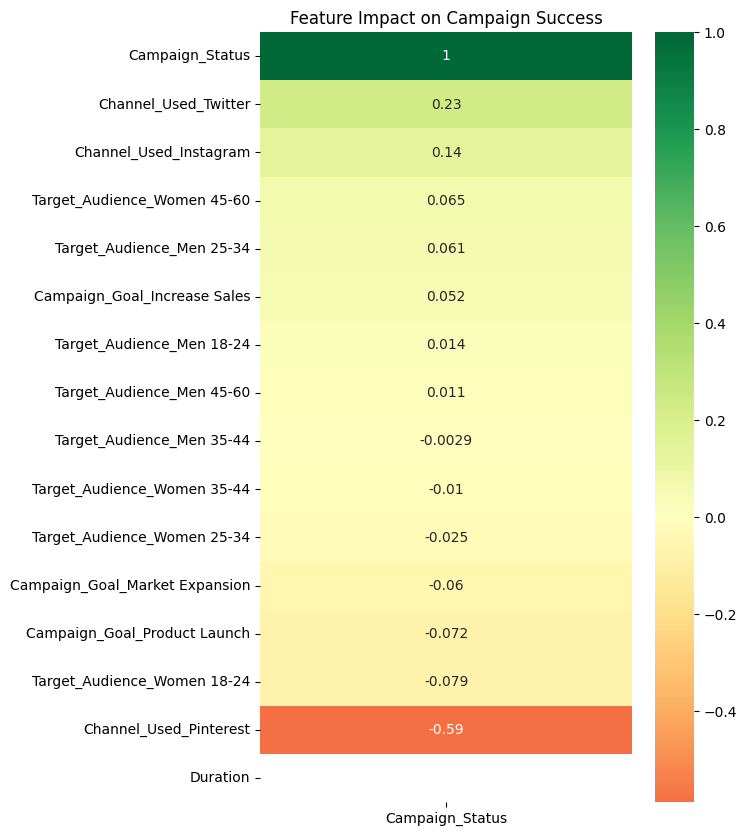

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use 'X' (which contains your encoded features) and 'y'
plot_df = X.copy()
plot_df['Campaign_Status'] = y.astype(int) 

# 2. Calculate correlation
corr = plot_df.corr()

# 3. Isolate the correlation relative to the target only
# This shows exactly how each X variable impacts Campaign_Status
target_corr = corr[['Campaign_Status']].sort_values(by='Campaign_Status', ascending=False)

# 4. Plot
plt.figure(figsize=(6, 10))
sns.heatmap(target_corr, annot=True, cmap='RdYlGn', center=0)

plt.title('Feature Impact on Campaign Success')
plt.show()

In [25]:
# --- STEP 4: MODEL IMPLEMENTATION ---
# Split data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
# Initialize and train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [27]:
# Make predictions
y_pred = model.predict(X_test)

In [28]:
# --- STEP 5: EVALUATION ---
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nAccuracy Score: {accuracy * 100:.2f}%")

Confusion Matrix:
[[19 12]
 [ 6 63]]

Accuracy Score: 82.00%
